In [4]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import seaborn as sns  # Optional for aesthetics
from scipy.stats import linregress
import datetime
from concave_hull import concave_hull, concave_hull_indexes
from sklearn.cluster import DBSCAN

data_path  = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0/'
fig_path   = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_fig15/'
shape_path = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_shape15/'

In [5]:
def find_connected_areas(points, epsilon, min_samples):
    # Convert the points to a NumPy array
    data = np.array(points)

    # Apply DBSCAN clustering
    dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
    labels = dbscan.fit_predict(data)

    # Create a dictionary to store connected areas
    connected_areas = {}
    for i, label in enumerate(labels):
        if label != -1:  # Ignore noise points
            if label not in connected_areas:
                connected_areas[label] = []
            connected_areas[label].append(tuple(data[i]))

    # Convert dictionary values to lists
    connected_areas = list(connected_areas.values())

    return connected_areas

In [9]:
# Open and read the missing_dates.txt file
with open('missing_dates.txt', 'r') as f:
    missing_dates = f.read().splitlines()

# Define data path and list of files
data_path = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0/'
file_list = glob.glob(data_path + '*/*/ice_conc_sh_*.nc')

# Find file paths corresponding to missing dates
missing_files = []
for file_path in file_list:
    date_str = file_path.split('/')[-1].split('_')[-1][:8]
    formatted_date = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:]}"
    if formatted_date in missing_dates:
        missing_files.append(file_path)


In [ ]:
#file_list = glob.glob(data_path+ '*/*/ice_conc_sh_*.nc')
n = 0
for n in np.arange(len(missing_files)):
    ds = xr.open_dataset(missing_files[n])
    ice_conc_mask = np.isnan(ds['ice_conc'])
    mask_dataarray = xr.DataArray(ice_conc_mask, coords=ds['ice_conc'].coords)
    mask_dataarray.name = 'ice_conc_mask'
    mask_dataarray_filtered = mask_dataarray.where(ds['lat'] <= -60, 0)
    ds = ds.assign(mask=mask_dataarray_filtered[:,:])

    #Get x,y points for land mask and SIC15
    ind_mask = np.where(ds.mask == 1)
    threshold_ice_conc = 15
    ind_SIC15 = np.where(ds.ice_conc > threshold_ice_conc)

    # Get the corresponding coordinates using the indices
    x_mask = ds.xc[ind_mask[2]].values
    y_mask = ds.yc[ind_mask[1]].values
    x_15 = ds.xc[ind_SIC15[2]].values
    y_15 = ds.yc[ind_SIC15[1]].values    
    x = np.concatenate((x_mask, x_15))
    y = np.concatenate((y_mask, y_15))
    points = np.vstack((x,y)).T

    epsilon = 25  # Maximum distance between points in the same neighborhood
    min_samples = 2  # Minimum number of samples in a neighborhood

    connected_areas = find_connected_areas(points, epsilon, min_samples)

    #Find length maximum of clusters and apply the hull on it 
    ca_size = np.array(connected_areas,dtype=object).size
    area_size = list(np.arange(ca_size))
    for i,area, in zip(np.arange(ca_size),connected_areas):
        area_size[i] = np.size(area)
    ind_max = np.argmax(area_size)
    V = connected_areas[ind_max]

    #Concave hull of the coastline + main sea ice shapes
    a_hull = np.array(concave_hull(V,concavity = .1))
 
    #Recenter to the Wester Peninsula
    x = a_hull[:,0]
    y = a_hull[:,1]
    target_point = np.array([-2550, 1300])
    distances = np.sqrt((x - target_point[0])**2 + (y - target_point[1])**2)
    min_distance_index = np.argmin(distances)
    Cx = np.concatenate((x[min_distance_index:], x[:min_distance_index]))
    Cy = np.concatenate((y[min_distance_index:], y[:min_distance_index]))

    #Plot
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(10, 10))
    for area in connected_areas:
        area = np.array(area)
        ax1.scatter(area[:, 0], area[:, 1], s = .1)

    ax1.plot(a_hull[:,0],a_hull[:,1],c = 'green',label = 'closed contour')

    #ds['ice_conc'].isel(time = t).plot(ax = ax2)
    ax2.contour(ds['xc'], ds['yc'], ds['ice_conc'].isel(time = 0)
                , levels=[threshold_ice_conc], colors='black')
    ax2.scatter(x_mask,y_mask,label ='coastline', s = .1)

    ax3.plot(Cx,Cy,c = 'green',label = 'closed contour')
    ax3.scatter(Cx[0],Cy[0],c = 'red',label = 'starting point', s = 30)

    ax4.plot(Cx)
    ax4.plot(Cy)
    ax1.set_title("Connected Areas of Points")
    ax2.set_title(str(threshold_ice_conc) + '% SIC contour')
    ax3.set_title('Single closed contour')
    ax4.set_title('Single closed contour (x and y)')
    ax2.legend()
    for ax in (ax1, ax2, ax3):
        ax.legend()
        ax.set_xlim([-4000,4000])
        ax.set_ylim([-4000,4000])
    plt.tight_layout()
    plt.savefig(fig_path + 'Fig15_' + str(ds.time.data[0])[0:10] + '.png')
    plt.close()
    
    #Save Netcdf
    ds = ds.assign(C15x=Cx,C15y=Cy)
    variables_to_keep = ['time', 'C15x', 'C15y']
    ds = ds.drop_vars([var for var in ds.variables if var not in variables_to_keep])
    ds.to_netcdf(shape_path + 'Shape15_' + str(ds.time.data[0])[0:10] + '.nc')

In [8]:
#Load all
file_list = glob.glob(shape_path + '*.nc')
ds = xr.open_dataset(file_list[0])
ds

<xarray.Dataset>
Dimensions:  (time: 1, C15x: 1203, C15y: 1203)
Coordinates:
  * time     (time) datetime64[ns] 2001-07-03T12:00:00
  * C15x     (C15x) float64 -2.512e+03 -2.488e+03 ... -2.462e+03 -2.488e+03
  * C15y     (C15y) float64 1.312e+03 1.288e+03 ... 1.312e+03 1.312e+03
Data variables:
    *empty*
Attributes: (12/43)
    title:                     Sea Ice Concentration Climate Data Record Vers...
    summary:                   This climate data record of sea ice concentrat...
    topiccategory:             Oceans ClimatologyMeteorologyAtmosphere
    geospatial_lat_min:        -90.0
    geospatial_lat_max:        -16.62393
    geospatial_lon_min:        -180.0
    ...                        ...
    algorithm:                 SICCI3LF (19V, 37V, 37H)
    references:                Product User Manual v3 (2022),Algorithm Theore...
    contributor_name:          Thomas Lavergne,Atle Soerensen,Rasmus Tonboe,C...
    contributor_role:          PrincipalInvestigator,author,author,author,aut...
    source:                    FCDR of SMMR / SSMI / SSMIS Brightness Tempera...
    product_status:            released

Text(0.5, 1.0, '2001-07-03')

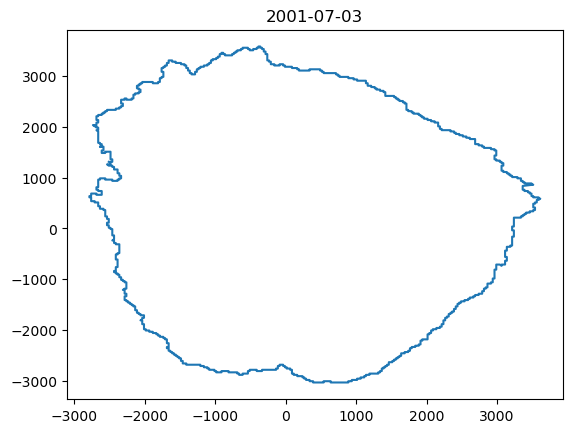

In [14]:
plt.plot(ds.C15x,ds.C15y)
plt.title(str(ds.time.data[0])[0:10])